In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Uncomment if you haven't install pyorbital
# %pip install pyorbital 

In [3]:
import dabench as dab
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import pyorbital
from pyorbital.orbital import Orbital
import datetime as dt

In [4]:
np_rng = np.random.default_rng(seed=5)

# Mimicing realistic observations

In [5]:
gcp = dab.data.GCP(date_start='2025-05-01', date_end='2025-05-14', min_lat=-85, max_lat=85, min_lon=0, max_lon=360)
gcp_nature_run = gcp.load()

## Radiosonde

In [6]:
per_min_drift_sd = 0.05

In [7]:
radiosonde_lat = [-22.5]
radiosonde_lon = [-43.3]
rad_times_gcp = np.arange(np.datetime64('2025-05-01T10:00:00.0000000'),np.datetime64('2025-05-01T14:00:00.0000000'), np.timedelta64(1, 'm'))
for t in rad_times_gcp[:-1]:
    radiosonde_lat.append(radiosonde_lat[-1] + np_rng.normal(loc=0, scale=per_min_drift_sd))
    radiosonde_lon.append(radiosonde_lon[-1] + np_rng.normal(loc=0, scale=per_min_drift_sd))


rad_locs_gcp= {
    'latitude':xr.DataArray(np.expand_dims(radiosonde_lat, 1), dims=('time','observations')),
    'longitude': xr.DataArray(np.expand_dims(radiosonde_lon, 1)%360, dims=('time','observations'))
}

In [8]:
# Set up observer using our specified sampling
rad_gcp = dab.observer.Observer(
    gcp_nature_run, 
    times = rad_times_gcp, # Time indices to sample
    locations = rad_locs_gcp, # Location indices to sample
    error_bias = 0.0, # No error this time
    error_sd = 0.0,
    sel_method='nearest',
    stationary_observers=False
)

# Making observations
rad_obs = rad_gcp.observe()

# Set times to those of observer, overwriting the times from ERA5 (the actual times sampled)
rad_obs = rad_obs.assign(time=('time',rad_times_gcp))

Text(0.25, -0.3, '$(b)$')

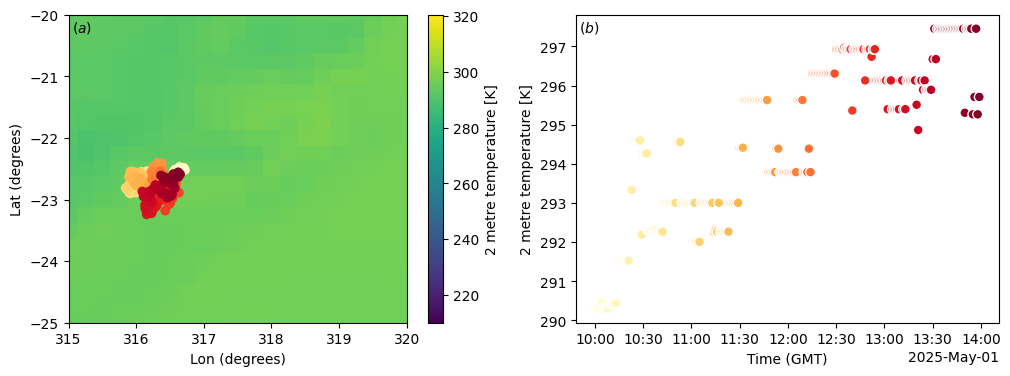

In [9]:

# Plot
fig, axs = plt.subplots(1,2, figsize=(12,4))
gcp_nature_run.isel(time=12)['2m_temperature'].plot(ax=axs[0])
axs[0].set_xlim(315,320)
axs[0].set_ylim(-25,-20)
axs[0].scatter(rad_locs_gcp['longitude'], rad_locs_gcp['latitude'], c=rad_times_gcp, cmap='YlOrRd')
rad_obs['2m_temperature'].plot.scatter(x='time', y='2m_temperature', hue='time', cmap='YlOrRd',
                                       add_colorbar=False, add_legend=False, s=50)
axs[0].set_title('')
axs[0].set_xlabel('Lon (degrees)')
axs[0].set_ylabel('Lat (degrees)')
axs[1].set_xlabel('Time (GMT)')
axs[0].annotate('$(a)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')
axs[1].annotate('$(b)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')

## Satellite

In the previous example, we specified locations to sample in the flattened, 1D space of the system's state vector. But for many data generators/loaders, the values originally exist in multi-dimensional space (e.g. latitudue, longitude, vertical level) before being flattened into a state vector. DataAssimBench's Observer class can take location indices in this original_dim instead. Let's create observations from some ERA5 data downloaded from Google Cloud.

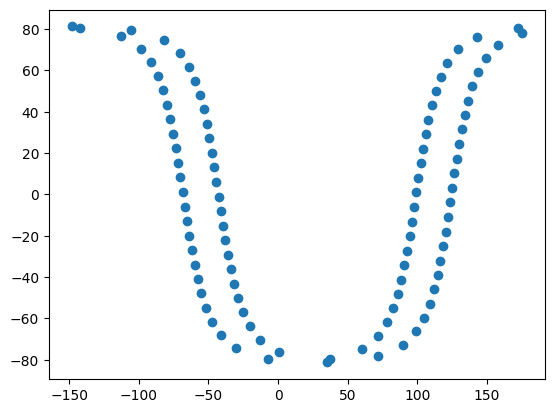

In [10]:
# Let's sample at the locations of the  METOP-C weather satellite for fun
orb = Orbital("METOP-C")
# orb.get_lonlatalt(np.datetime64('2025-05-01'))
# dt_list = gcp_nature_run.time.values #np.arange(gcp_nature_run.time[0], np.datetime64('2017-01-08'))
sat_times_gcp = np.arange(gcp_nature_run.isel(time=0).time.values,np.datetime64('2025-05-01T03:20:00.0000000'), np.timedelta64(2, 'm'))

# # Week's worth of datetimes
# start_dt =  = dt.datetime.now()
# start_dt = end_dt - dt.timedelta(hours=6)
# dt_list = [start_dt + dt.timedelta(minutes=x) for x in range(60*6)]

lon_list = []
lat_list = []
for datetime in sat_times_gcp:
    loc = orb.get_lonlatalt(datetime)
    lon_list.append(loc[0])
    lat_list.append(loc[1])


plt.scatter(lon_list, lat_list)
plt.show()


In [11]:

# Let's pick indices at the corners and roughly center of the system
sat_locs_gcp= {
    'latitude':xr.DataArray(np.expand_dims(lat_list, 1), dims=('time', 'observations')),
    'longitude': xr.DataArray(np.expand_dims(lon_list,1)%360, dims=('time', 'observations')),
}

In [12]:
# Set up observer using our specified sampling
sat_gcp = dab.observer.Observer(
    gcp_nature_run, 
    times = sat_times_gcp, # Time indices to sample
    locations = sat_locs_gcp, # Location indices to sample
    error_bias = 0.0, # No error this time
    error_sd = 0.0,
    sel_method='nearest',
    stationary_observers=False
)

# Making observations
sat_obs = sat_gcp.observe()

# Set times to those of observer, overwriting the times from ERA5 (the actual times sampled)
sat_obs = sat_obs.assign(time=('time',sat_times_gcp))

Text(0.25, -0.3, '$(b)$')

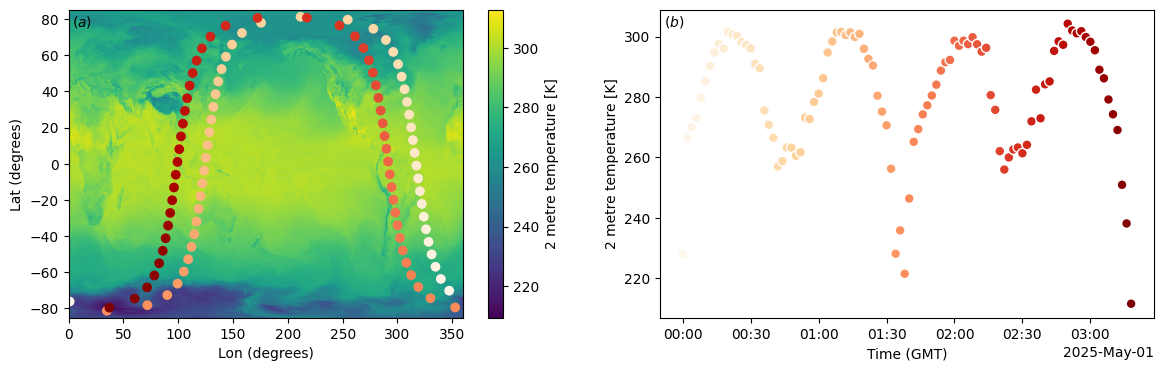

In [13]:
# Plot
fig, axs = plt.subplots(1,2, figsize=(14,4))
gcp_nature_run.isel(time=0)['2m_temperature'].plot(ax=axs[0])
axs[0].scatter(sat_locs_gcp['longitude'], sat_locs_gcp['latitude'], c=sat_times_gcp, cmap='OrRd')
sat_obs['2m_temperature'].plot.scatter(ax=axs[1],x='time', y='2m_temperature', hue='time', cmap='OrRd',
                                       add_colorbar=False, add_legend=False,s=50)
axs[0].set_title('')
axs[0].set_xlabel('Lon (degrees)')
axs[0].set_ylabel('Lat (degrees)')
axs[1].set_xlabel('Time (GMT)')
axs[0].annotate('$(a)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')
axs[1].annotate('$(b)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')

Text(0.25, -0.3, '$(d)$')

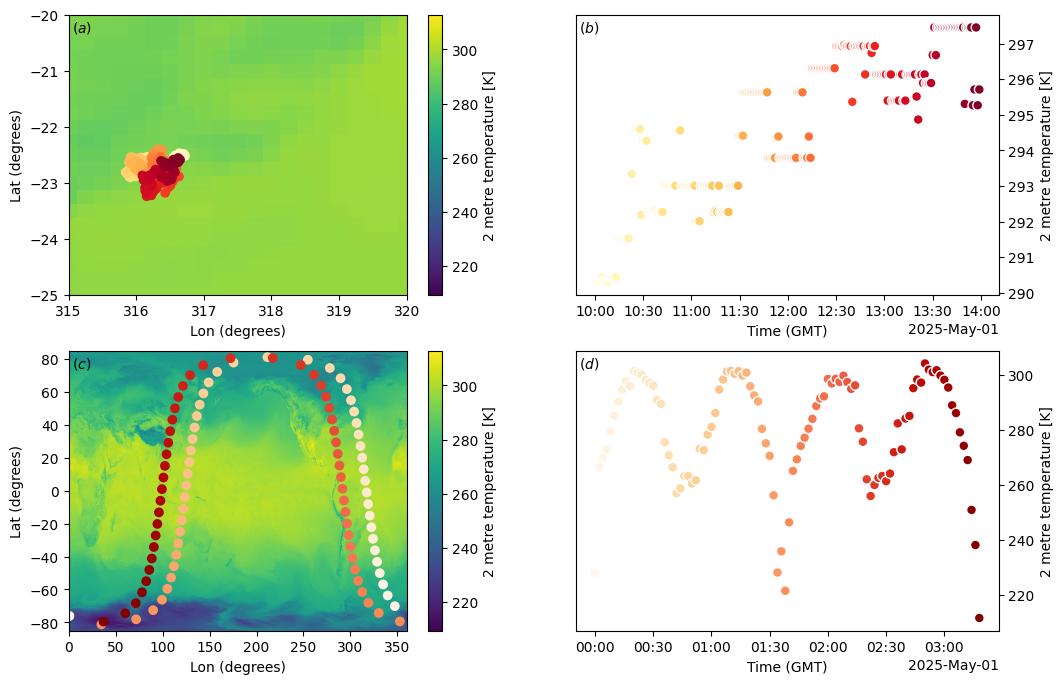

In [14]:
# Combined plot
# Plot
fig, axs = plt.subplots(2,2, figsize=(12,8))

# Radiosonde
gcp_nature_run.isel(time=0)['2m_temperature'].plot(ax=axs[0,0])
axs[0,0].set_xlim(315,320)
axs[0,0].set_ylim(-25,-20)
axs[0,0].scatter(rad_locs_gcp['longitude'], rad_locs_gcp['latitude'], c=rad_times_gcp, cmap='YlOrRd')
rad_obs['2m_temperature'].plot.scatter(ax=axs[0,1],x='time', y='2m_temperature', hue='time', cmap='YlOrRd',
                                       add_colorbar=False, add_legend=False, s=50)
axs[0, 0].set_title('')
axs[0, 0].set_xlabel('Lon (degrees)')
axs[0, 0].set_ylabel('Lat (degrees)')
axs[0, 1].set_xlabel('Time (GMT)')
axs[0, 0].annotate('$(a)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')
axs[0, 1].annotate('$(b)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')


#Satellite
gcp_nature_run.isel(time=0)['2m_temperature'].plot(ax=axs[1,0])
axs[1, 0].scatter(sat_locs_gcp['longitude'], sat_locs_gcp['latitude'], c=sat_times_gcp, cmap='OrRd')
sat_obs['2m_temperature'].plot.scatter(ax=axs[1,1],x='time', y='2m_temperature', hue='time', cmap='OrRd',
                                       add_colorbar=False, add_legend=False,s=50)
axs[1, 0].set_title('')
axs[1, 0].set_xlabel('Lon (degrees)')
axs[1, 0].set_ylabel('Lat (degrees)')
axs[1, 1].set_xlabel('Time (GMT)')
axs[1, 1].yaxis.tick_right()
axs[0, 1].yaxis.tick_right()
axs[0, 1].yaxis.set_label_position("right")
axs[1, 1].yaxis.set_label_position("right")
axs[1, 0].annotate('$(c)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')
axs[1, 1].annotate('$(d)$', xy=(0, 1), xycoords='axes fraction',
        xytext=(+0.25, -0.3), textcoords='offset fontsize',
        fontsize='medium', verticalalignment='top', fontfamily='serif')